In [1]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-train.csv to Titanic-train (2).csv


In [3]:
titanic_df = pd.read_csv(io.BytesIO(uploaded["Titanic-train.csv"]))
display(titanic_df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
# count of Missing Values
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

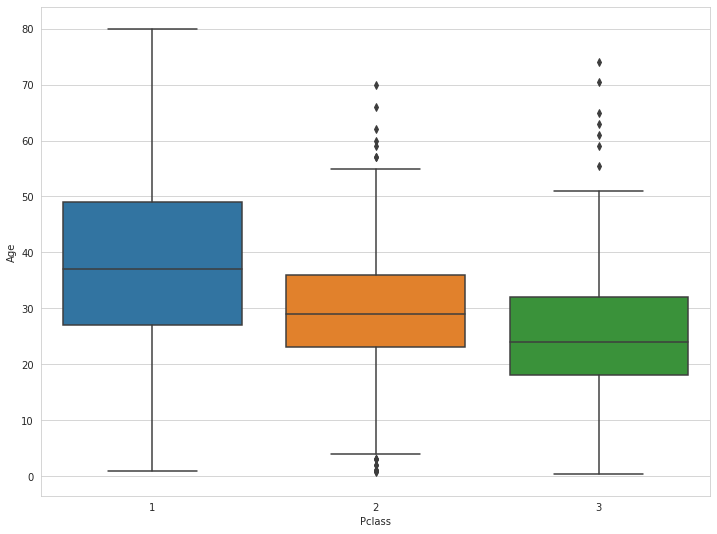

In [5]:
sns.set_style("whitegrid")
plt.figure(figsize = (12,9))
sns.boxplot(x = "Pclass", y = "Age", data = titanic_df)

In [6]:
titanic_df[titanic_df['Pclass'] == 1]['Age'].median()

37.0

In [7]:
titanic_df[titanic_df['Pclass'] == 2]['Age'].median()

29.0

In [8]:
titanic_df[titanic_df['Pclass'] == 3]['Age'].median()

24.0

In [9]:
# Simple Imputer
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age

In [10]:
titanic_df['Age'] = titanic_df[['Age', 'Pclass']].apply(impute_age, axis = 1)

In [11]:
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
titanic_df.drop(['Cabin'], axis = 1, inplace=True)

In [13]:
titanic_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [14]:
# Dropna() - Drops entire rows of data if less rows are missing
# Drops embarked missing rows 
titanic_df.dropna(inplace = True)

In [15]:
titanic_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [16]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [17]:
X = titanic_df.drop(["PassengerId", "Survived", "Name", "Sex", "Ticket", "Embarked"], axis = 1)
y = titanic_df['Survived']

In [18]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

In [19]:
# Import the class: Logistic Regression 
from sklearn.linear_model import LogisticRegression
# instantiate the model (using the default parameters)
logreg = LogisticRegression()

In [20]:
# fit the model with data
logreg.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [21]:
# Accuracy of Testing
logreg.score(X_test, y_test)

0.6591760299625468

In [22]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
predictions = logreg.predict(X_test)

confusion_matrix(y_test, predictions)

array([[128,  29],
       [ 62,  48]])

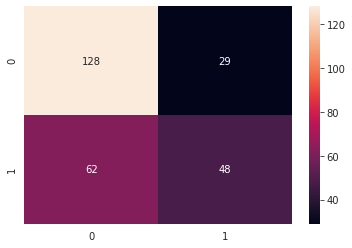

In [23]:
sns.heatmap(confusion_matrix(y_test, predictions), annot = True, fmt='0.0f')

In [24]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.67      0.82      0.74       157
           1       0.62      0.44      0.51       110

    accuracy                           0.66       267
   macro avg       0.65      0.63      0.63       267
weighted avg       0.65      0.66      0.65       267



In [25]:
# X_test
X_Jack = [[3,	24.0,	0,	0,	8.2500]]
X_Rose = [[1,	22.0,	0,	0,	71.2500]]

In [26]:
logreg.predict(X_Jack)

array([0])

In [27]:
logreg.predict(X_Rose)

array([1])

In [28]:
# Model Evaluation using Confusion Matrix
y_pred = logreg.predict(X_test)
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[128,  29],
       [ 62,  48]])

Text(0.5, 257.44, 'Predicted label')

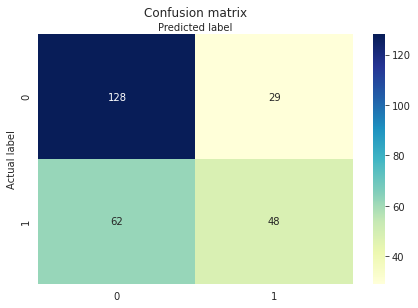

In [29]:
# Visualizing Confusion Matrix using Heatmap
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [30]:
# Confusion Matrix Evaluation Metrics
# Evaluate the model using model evaluation metrics such as accuracy, precision, and recall.
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))

Accuracy: 0.6591760299625468
Precision: 0.6233766233766234
Recall: 0.43636363636363634


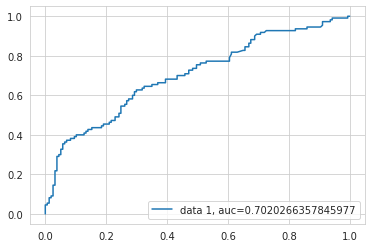

In [31]:
# ROC Curve
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()